# Descripción del problema
Se analiza el comportamiento de los clientes para identificar qué variables ayudan a distinguir entre clientes activos y cancelados.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

sns.set(style='whitegrid')

# Carga del dataset
Se lee el archivo CSV con la información de clientes para comenzar el análisis.

In [2]:
sampled_data = pd.read_csv('DaviData.csv')

# Exploración inicial de los datos
Se revisa el contenido del DataFrame para ver la estructura básica de la información cargada.

In [3]:
sampled_data

,CLIENTNUM,Segmento,Edad,Genero,Antiguedad_meses,Relaciones_activas,Ingresos,Transacciones_ct,Transacciones_amt,Saldo_rotativo,Limite_credito,Ratio_utilizacion,Estado_cliente,Probabilidad_abandono
0,1001,Alta Renta,45,F,120,5,Alta,85,250000,15000,80000,0.45,Activo,0.12
1,1002,Digital,32,M,48,3,Media,40,75000,5000,30000,0.25,Cancelado,0.78
2,1003,Nómina,29,F,36,2,Baja,25,30000,2000,15000,0.18,Activo,0.22
3,1004,Alta Renta,52,M,180,6,Alta,120,400000,20000,100000,0.60,Activo,0.09
4,1005,Digital,41,F,60,4,Media,55,120000,8000,50000,0.35,Activo,0.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1096,Nómina,30,M,45,2,Baja,29,41000,2550,16500,0.15,Activo,0.20
96,1097,Alta Renta,50,F,162,5,Alta,114,365000,20200,96000,0.54,Activo,0.09
97,1098,Digital,37,M,81,4,Media,71,152000,10900,64500,0.41,Activo,0.29
98,1099,Nómina,38,F,89,4,Baja,49,87000,6050,35500,0.28,Activo,0.23


# Separación entre clientes activos y cancelados
Se dividen los clientes en dos grupos para comparar el comportamiento de quienes siguen activos y quienes cancelaron.

In [4]:
clientes_activos = sampled_data[sampled_data['Estado_cliente'] == 'Activo']
clientes_cancelados = sampled_data[sampled_data['Estado_cliente'] == 'Cancelado']

print('Clientes activos:', len(clientes_activos))
print('Clientes cancelados:', len(clientes_cancelados))

Clientes activos: 88
Clientes cancelados: 12


# Entrenamiento, accuracy y ROC
Se prepara el objetivo, se entrena un modelo Random Forest y se evalúa su rendimiento con accuracy, reporte de clasificación y curva ROC.

Accuracy: 0.8667
ROC AUC: 0.8542

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        24
           1       0.67      0.67      0.67         6

    accuracy                           0.87        30
   macro avg       0.79      0.79      0.79        30
weighted avg       0.87      0.87      0.87        30



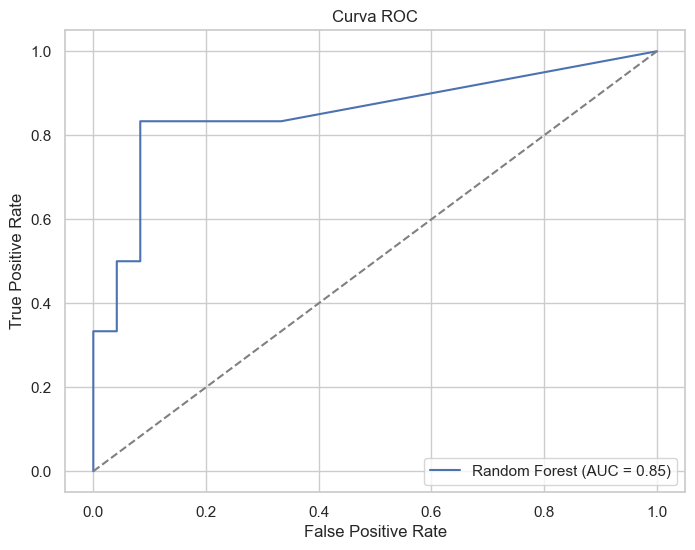

In [5]:
df_model = sampled_data.copy()
y = df_model['Estado_cliente'].map({'Activo': 0, 'Cancelado': 1})
X = df_model.drop(columns=['Estado_cliente', 'Probabilidad_abandono'])
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.3,
    random_state=42
)

random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

predictions = random_forest_model.predict(X_test)
probabilities = random_forest_model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, predictions)
auc = roc_auc_score(y_test, probabilities)

print('Accuracy:', round(accuracy, 4))
print('ROC AUC:', round(auc, 4))
print('\nReporte de clasificación:\n')
print(classification_report(y_test, predictions))

fpr, tpr, _ = roc_curve(y_test, probabilities)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

# Importancia de variables
Se muestran las 10 variables más importantes según el Random Forest entrenado.

/var/folders/xn/hk31cmbn33j2sp_0424kxs940000gn/T/ipykernel_38335/3466494871.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='viridis')


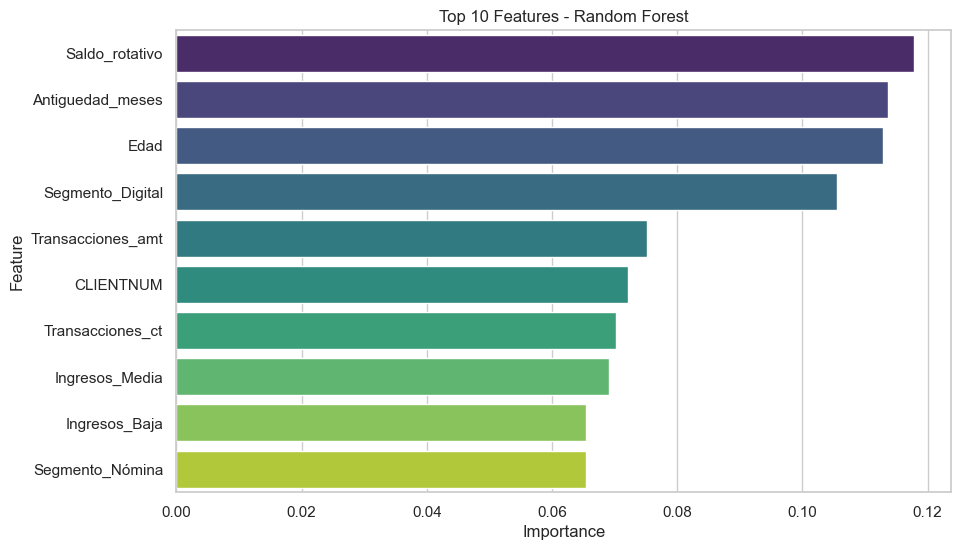

,Feature,Importance
0,Saldo_rotativo,0.117894
1,Antiguedad_meses,0.113734
2,Edad,0.112833
3,Segmento_Digital,0.105493
4,Transacciones_amt,0.075098
5,CLIENTNUM,0.072085
6,Transacciones_ct,0.070218
7,Ingresos_Media,0.069058
8,Ingresos_Baja,0.065490
9,Segmento_Nómina,0.065436


In [6]:
feature_importances = random_forest_model.feature_importances_
features_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': feature_importances
})
features_df = features_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='viridis')
plt.title('Top 10 Features - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

features_df.head(10)

# Tabla de predicciones vs reales
Se muestra una tabla con `y_test`, predicción, y probabilidad de churn, además de la matriz de confusión.

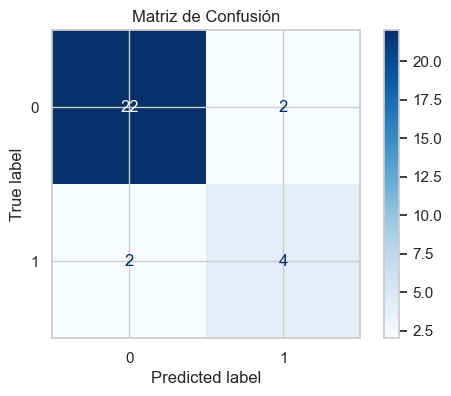

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred_df = pd.DataFrame({
    'y_true': y_test.values,
    'prediction': predictions,
    'probability': probabilities
}, index=y_test.index)

# Mostrar primeras filas de la tabla
pred_df_display = pred_df.sort_values(by='probability', ascending=False)
pred_df_display.head(20)

# Matriz de confusión
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
fig, ax = plt.subplots(figsize=(6,4))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión')
plt.show()